<a href="https://colab.research.google.com/github/LauraSiemens/dvrk_auto_path_finder/blob/main/ferangi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-image!

In [3]:
!git clone https://github.com/LauraSiemens/dvrk_auto_path_finder.git

Cloning into 'dvrk_auto_path_finder'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 25 (delta 4), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 258.05 KiB | 28.67 MiB/s, done.
Resolving deltas: 100% (4/4), done.


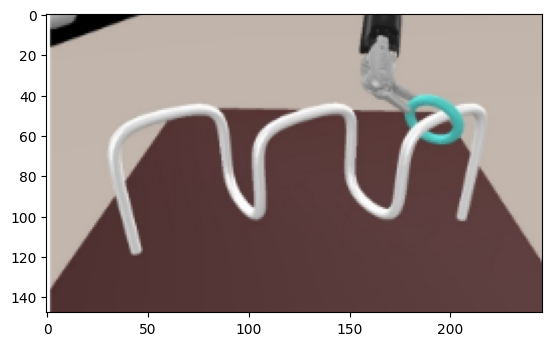

In [4]:
from skimage import io
import matplotlib.pyplot as plt

img_path = '/content/dvrk_auto_path_finder/images/dvrk_from_canvas.png'
img = io.imread(img_path)
plt.imshow(img)

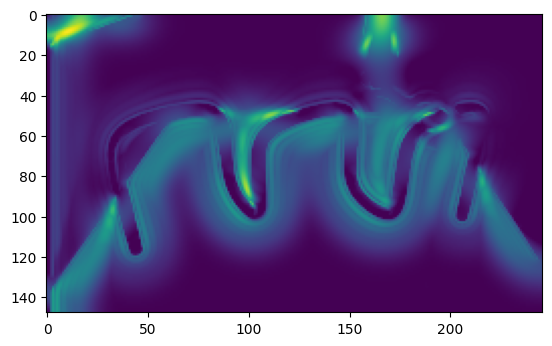

In [5]:
from skimage.filters import frangi, sato
from skimage import color

#other ones inlude meijering, frangi, hessian
rgb_array = img[:, :, :3]
image = color.rgb2gray(rgb_array)
frangi_image = sato(image)
binary = (frangi_image == 0).astype(np.uint8)
plt.imshow(binary)



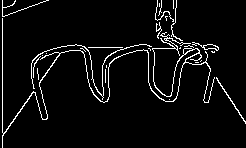

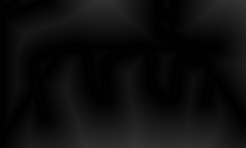

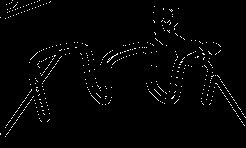

-1

In [22]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# detect edges
edges = cv2.Canny(gray, 50, 150)

# invert for distance transform
binary = (edges == 0).astype(np.uint8)

# compute distance map
dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

# keep pixels 5–10 px from nearest edge
mask = ((dist > 2) & (dist < 2.5)).astype(np.uint8) * 255

cv2_imshow(edges)
cv2_imshow(dist)
cv2_imshow(mask)
cv2.waitKey(0)
